In [13]:
import numpy as np
path = "/root/work/dhn/results/sinpend_kernel2_stride1/gen_sequence/denoise1_update1/result_dict.npy"
path_cond = "/root/work/dhn/results/sinpend_kernel2_stride1/gen_sequence/denoise1_update1/cond_dict.npy"
result=np.load(path, allow_pickle=True).item()
cond=np.load(path_cond, allow_pickle=True).item()

In [5]:
p_scale=result["p_scale"]
t=result["t"]
q_gt=result["q_gt"]
q_pred=result["q_pred"]
t.shape, q_gt.shape, q_pred.shape,p_scale.shape, result.keys()

((1000, 128),
 (1000, 128, 1),
 (1000, 128, 1),
 (1000,),
 dict_keys(['t', 'q_gt', 'p_gt', 'q_pred', 'p_pred', 'p_scale']))

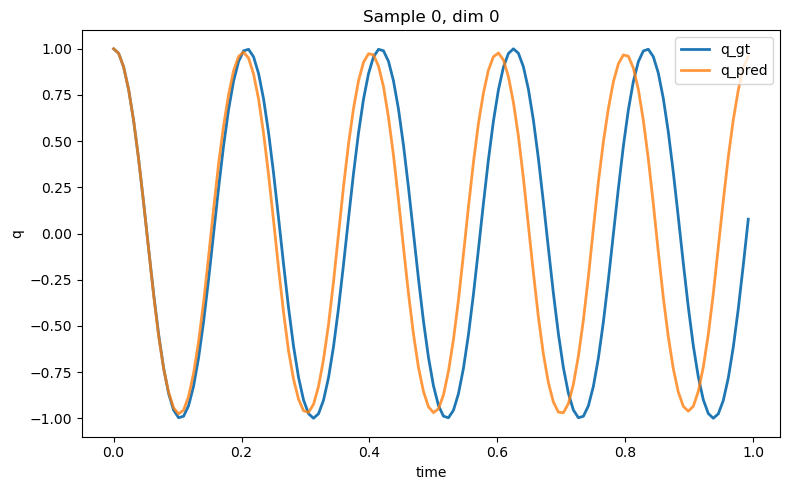

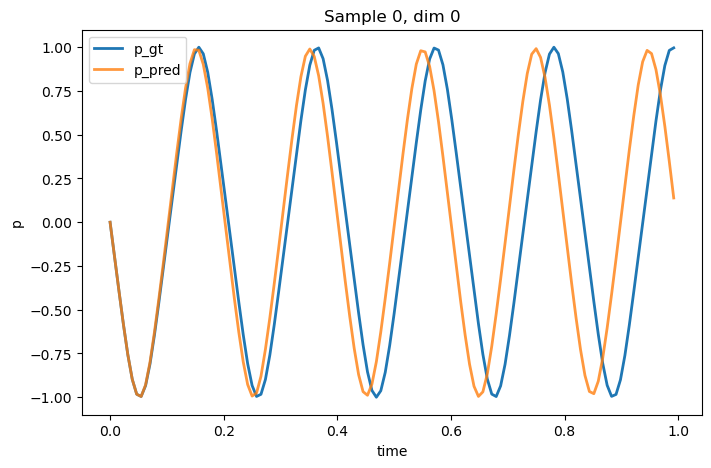

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Change these to your actual gen folder
gen_dir = "/root/work/dhn/results/sinpend_kernel2_stride1/gen_sequence"
# If there are multiple gen configs inside, pick one
# e.g., "ns20_stepsize1" — list directories to see what's there
subdirs = [d for d in os.listdir(gen_dir) if os.path.isdir(os.path.join(gen_dir, d))]
assert subdirs, f"No subdirectories found in {gen_dir}"
cfg_dir = os.path.join(gen_dir, subdirs[0])

result = np.load(os.path.join(cfg_dir, "result_dict.npy"), allow_pickle=True).item()

t = result["t"]          # shape: [N, T, 1]
q_gt = result["q_gt"]    # shape: [N, T, D]
q_pred = result["q_pred"]# shape: [N, T, D]

p_gt=result["p_gt"]
p_pred=result["p_pred"]

i = 0      # sample index to visualize
d = 0      # dimension index (0 for single pendulum)

tt = t[i]
plt.figure(figsize=(8,5))
plt.plot(tt, q_gt[i,:,d], label="q_gt", lw=2)
plt.plot(tt, q_pred[i,:,d], label="q_pred", lw=2, alpha=0.8)
plt.xlabel("time")
plt.ylabel("q")
plt.title(f"Sample {i}, dim {d}")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(tt, p_gt[i,:,d], label="p_gt", lw=2)
plt.plot(tt, p_pred[i,:,d], label="p_pred", lw=2, alpha=0.8)
plt.xlabel("time")
plt.ylabel("p")
plt.title(f"Sample {i}, dim {d}")
plt.legend()

## Visualize the results for the two body problem

In [ ]:
q_residual = np.abs(q_gt - q_pred).squeeze(-1)
q_residual=q_residual.mean(axis=0)

(128,)

/tmp/ipykernel_936880/3131403702.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


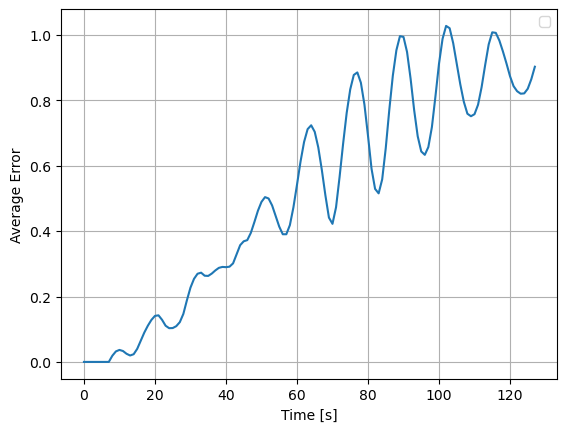

In [12]:
plt.plot(q_residual)
plt.xlabel('Time [s]')
plt.ylabel('Average Error')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
result.keys(), result['q_pred'].shape

(dict_keys(['t', 'q_gt', 'p_gt', 'q_pred', 'p_pred', 'p_scale']),
 (1000, 128, 1))

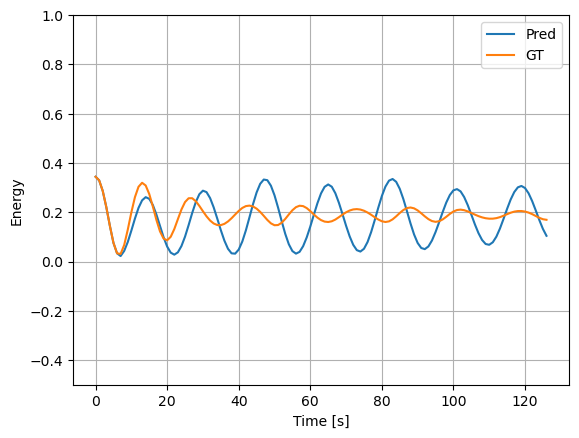

In [45]:
# Now let's calculate the energy over time

# Energy for a single pendulum as a function of angle
m=1
g=1
l=cond['l'] # (1000,)
q = result['q_pred'] # (1000, 128, 1)
q_gt = result['q_gt']

# dt = t[0][1] - t[0][0]
dt=1

q=q.squeeze(-1)
dq = (q[:,1:] - q[:, :-1])/dt

q_gt = q_gt.squeeze(-1)
dq_gt = (q_gt[:,1:] - q_gt[:, :-1])/dt

V = m*g*l[:,None]*(1-np.cos(q))
T = 0.5 * m * (l[:,None] * dq )**2

V_gt = m*g*l[:,None]*(1-np.cos(q_gt))
T_gt = 0.5 * m * (l[:,None] * dq_gt )**2

E = T + V[:,:-1]
E_gt = T_gt + V_gt[:,:-1]

plt.plot(E.mean(axis=0), label='Pred')
plt.plot(E_gt.mean(axis=0), label='GT')
plt.ylim(-0.5,1)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Energy')
plt.grid(True)
plt.show()


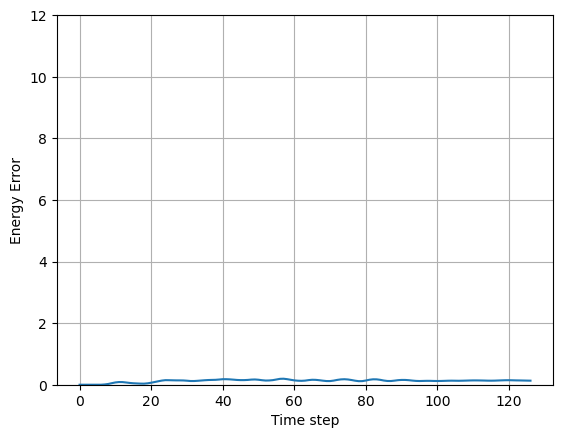

In [ ]:
# Let's also do energy error per time step

E_error = np.abs(E - E_gt)
plt.plot(E_error.mean(axis=0))
plt.xlabel('Time step')
plt.ylabel('Energy Error')
plt.grid(True)
plt.ylim(0,12)
plt.show()
